# ⚾ MLB Research Toolkit — Statcast Edition

**Single data source: Baseball Savant via `pybaseball`.**
No FanGraphs. No BBref. Just Statcast.

| 🎯 View | Built on |
|---|---|
| 🔴 **1. Opponent Scouting** | `statcast()` aggregated by team |
| 🟠 **2. Team Evaluation** | `statcast()` aggregated by player |
| 🟢 **3. Player Development** | `statcast_batter()` vs peer pool |
| 🔵 **4. Agents** | `statcast_batter()` percentiles + WAR proxy |

**Key Statcast columns:** `launch_speed` · `launch_angle` · `launch_speed_angle`
· `estimated_woba_using_speedangle` · `woba_value` · `woba_denom`
· `description` · `events` · `home_team` · `away_team` · `inning_topbot` · `zone`

---

In [1]:
# 📦 SETUP — run once per session
!pip install pybaseball matplotlib seaborn scipy --quiet

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.stats import percentileofscore

import pybaseball as pb
from pybaseball import (
    statcast,
    statcast_batter,
    statcast_pitcher,
    playerid_lookup,
)
pb.cache.enable()

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 110

# ── GLOBAL CONFIG ─────────────────────────────────────────
SEASON = 2026
START  = f'{SEASON}-04-01'
END    = f'{SEASON}-09-30'

# ── Statcast constants ────────────────────────────────────
PITCH_NAMES = {
    'FF':'Four-Seam FB','SI':'Sinker','FC':'Cutter','SL':'Slider',
    'SW':'Sweeper','ST':'Sweeping Curve','CU':'Curveball','KC':'Knuckle Curve',
    'CH':'Changeup','FS':'Splitter','FO':'Forkball','KN':'Knuckleball',
}
SWING_EVENTS   = ['swinging_strike','swinging_strike_blocked','foul_tip']
CONTACT_EVENTS = ['foul','foul_bunt','hit_into_play',
                  'hit_into_play_no_out','hit_into_play_score','missed_bunt']
IN_ZONE        = list(range(1, 10))
BARREL_CODE    = 6          # launch_speed_angle value for Barrel

# Update these each season from baseballsavant.mlb.com/league
LG_WOBA        = 0.320
WOBA_SCALE     = 1.15
DOLLARS_PER_WAR = 8_000_000

print('✅ Setup complete — strictly Statcast')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.3 MB/s eta 0:00:00
✅ Setup complete — strictly Statcast


In [2]:
# 🔧 HELPERS

def get_ids(last, first, row=0):
    """Return MLBAM id and name dict from playerid_lookup."""
    t = playerid_lookup(last, first)
    if t.empty:
        raise ValueError(f'No player found: {first} {last}')
    r = t.iloc[row]
    return {
        'name' : f"{r['name_first'].title()} {r['name_last'].title()}",
        'mlbam': int(r['key_mlbam']),
        'bbref': r['key_bbref'],
    }

def pctile(pop, val, lower_better=False):
    """Percentile of val in pop — higher output always means better."""
    s = pd.Series(pop).dropna()
    if s.empty or pd.isna(val): return np.nan
    p = percentileofscore(s, val, kind='rank')
    return round(100 - p if lower_better else p, 1)

def tag(df):
    """Add pitch_label column to a Statcast DataFrame."""
    df = df[df['pitch_type'].notna()].copy()
    df['pitch_label'] = df['pitch_type'].map(PITCH_NAMES).fillna(df['pitch_type'])
    return df

def batter_sc(mlbam, start=START, end=END):
    return tag(statcast_batter(start, end, player_id=mlbam))

def pitcher_sc(mlbam, start=START, end=END):
    return tag(statcast_pitcher(start, end, player_id=mlbam))

def quality_summary(df):
    """
    Compute quality metrics from any Statcast DataFrame.
    Works on a single player pull OR a filtered slice of a bulk pull.
    """
    bbe = df[df['launch_speed'].notna()]
    out = {'Pitches': len(df), 'BBE': len(bbe)}

    if len(bbe):
        out['Avg_EV']     = bbe['launch_speed'].mean()
        out['Max_EV']     = bbe['launch_speed'].max()
        out['Avg_LA']     = bbe['launch_angle'].mean()
        out['Barrel%']    = (bbe['launch_speed_angle'] == BARREL_CODE).mean() * 100
        out['HardHit%']   = (bbe['launch_speed'] >= 95).mean() * 100
        out['SweetSpot%'] = bbe['launch_angle'].between(8, 32).mean() * 100

    if 'estimated_woba_using_speedangle' in bbe.columns and len(bbe):
        out['xwOBA'] = bbe['estimated_woba_using_speedangle'].mean()
    if 'estimated_ba_using_speedangle' in bbe.columns and len(bbe):
        out['xBA']   = bbe['estimated_ba_using_speedangle'].mean()

    if {'woba_value','woba_denom'} <= set(df.columns):
        denom = df['woba_denom'].sum()
        if denom: out['wOBA'] = df['woba_value'].sum() / denom

    oz = df[~df['zone'].isin(IN_ZONE)]
    if len(oz):
        out['Chase%'] = oz['description'].isin(SWING_EVENTS+CONTACT_EVENTS).mean() * 100

    swings = df['description'].isin(SWING_EVENTS+CONTACT_EVENTS).sum()
    if swings:
        out['Whiff%'] = df['description'].isin(SWING_EVENTS).sum() / swings * 100

    out['CSW%'] = df['description'].isin(SWING_EVENTS+['called_strike']).mean() * 100

    return out

def batting_war_proxy(df):
    """
    Batting-only WAR proxy from Statcast wOBA.
    Formula: (wOBA - lgwOBA) / wOBAscale * PA / runsPerWin
    Use the df already loaded — no extra network call needed.
    """
    if df.empty or 'woba_value' not in df.columns: return 0.0
    denom = df['woba_denom'].sum()
    if not denom: return 0.0
    woba = df['woba_value'].sum() / denom
    pa   = df['events'].notna().sum()
    runs_above = (woba - LG_WOBA) / WOBA_SCALE * pa
    return round(runs_above / 10, 1)  # ~10 runs per WAR

def team_offense(sc_df, team_abbr):
    """Aggregate Statcast bulk pull for one batting team."""
    df = sc_df.copy()
    df['bat_team'] = np.where(df['inning_topbot']=='Bot', df['home_team'], df['away_team'])
    t  = df[df['bat_team'] == team_abbr]
    if t.empty: return {}
    bbe = t[t['launch_speed'].notna()]
    out = {
        'PA'       : t[t['events'].notna()]['events'].count(),
        'Avg_EV'   : bbe['launch_speed'].mean() if len(bbe) else np.nan,
        'HardHit%' : (bbe['launch_speed']>=95).mean()*100 if len(bbe) else np.nan,
        'Barrel%'  : (bbe['launch_speed_angle']==BARREL_CODE).mean()*100 if len(bbe) else np.nan,
        'Chase%'   : t[~t['zone'].isin(IN_ZONE)]['description'].isin(
                         SWING_EVENTS+CONTACT_EVENTS).mean()*100,
        'Whiff%'   : t['description'].isin(SWING_EVENTS).sum() /
                     max(t['description'].isin(SWING_EVENTS+CONTACT_EVENTS).sum(),1)*100,
    }
    if 'estimated_woba_using_speedangle' in bbe.columns and len(bbe):
        out['xwOBA'] = bbe['estimated_woba_using_speedangle'].mean()
    if {'woba_value','woba_denom'} <= set(t.columns):
        denom = t['woba_denom'].sum()
        if denom: out['wOBA'] = t['woba_value'].sum() / denom
    return out

def team_pitching_agg(sc_df, team_abbr):
    """Aggregate Statcast bulk pull for one pitching team."""
    df = sc_df.copy()
    df['pit_team'] = np.where(df['inning_topbot']=='Top', df['home_team'], df['away_team'])
    t  = df[df['pit_team'] == team_abbr]
    if t.empty: return {}
    bbe = t[t['launch_speed'].notna()]
    out = {
        'EV_allowed'      : bbe['launch_speed'].mean() if len(bbe) else np.nan,
        'HardHit%_allowed': (bbe['launch_speed']>=95).mean()*100 if len(bbe) else np.nan,
        'Barrel%_allowed' : (bbe['launch_speed_angle']==BARREL_CODE).mean()*100 if len(bbe) else np.nan,
        'Whiff%_induced'  : t['description'].isin(SWING_EVENTS).sum() /
                            max(t['description'].isin(SWING_EVENTS+CONTACT_EVENTS).sum(),1)*100,
        'Chase%_induced'  : t[~t['zone'].isin(IN_ZONE)]['description'].isin(
                                SWING_EVENTS+CONTACT_EVENTS).mean()*100,
    }
    if 'estimated_woba_using_speedangle' in bbe.columns and len(bbe):
        out['xwOBA_against'] = bbe['estimated_woba_using_speedangle'].mean()
    return out

def rank_table(league_df, team, metrics, lower_set):
    """Build a percentile rank table for one team vs the rest of the league."""
    tgt = league_df[league_df['Team'] == team]
    if tgt.empty:
        print(f'⚠️  {team} not found. Available teams:',
              sorted(league_df['Team'].dropna().unique()))
        return pd.DataFrame()
    rows = []
    for m in metrics:
        if m not in league_df.columns: continue
        val = tgt[m].iloc[0]
        if pd.isna(val): continue
        rows.append({'Metric': m, 'Value': round(val,3),
                     'Pctile': pctile(league_df[m], val, m in lower_set)})
    return pd.DataFrame(rows).sort_values('Pctile', ascending=False)

print('✅ Helpers loaded')

✅ Helpers loaded


---
# 🔴 1. Opponent Scouting
*"What are their strengths? Where can we attack? How will each player hurt us?"*

> ⏳ `statcast()` pulls ~700k rows/month. Narrow `SCOUT_START`/`SCOUT_END` and cache aggressively.
> ⚠️ Team abbreviations are Statcast-style: `WSH` not `WSN`, `ARI` not `AZ`.
> If a team is missing, the cell will print the available list.

In [7]:
# ── CONFIGURE ─────────────────────────────────────────────
OPPONENT_ABBR = 'BAL'
SCOUT_START   = START   # Use full season start date
SCOUT_END     = END     # Use full season end date
# ──────────────────────────────────────────────────────────

print(f'⏳ Pulling Statcast {SCOUT_START} → {SCOUT_END} ...')
sc = statcast(SCOUT_START, SCOUT_END)
print(f'✅ {len(sc):,} pitches loaded')
print('Teams in dataset:', sorted(set(sc['home_team'].dropna()) | set(sc['away_team'].dropna())))

# ── Build league-wide team tables ─────────────────────────
all_teams = sorted(set(sc['home_team'].dropna()) | set(sc['away_team'].dropna()))
off_rows, pit_rows = [], []
for team in all_teams:
    o = team_offense(sc, team)
    p = team_pitching_agg(sc, team)
    if o: off_rows.append({'Team': team, **o})
    if p: pit_rows.append({'Team': team, **p})
league_off = pd.DataFrame(off_rows)
league_pit = pd.DataFrame(pit_rows)

OFF_METRICS = ['xwOBA','wOBA','Avg_EV','HardHit%','Barrel%','Chase%','Whiff%']
PIT_METRICS = ['xwOBA_against','EV_allowed','HardHit%_allowed',
               'Barrel%_allowed','Whiff%_induced','Chase%_induced']
OFF_LOWER   = {'Chase%','Whiff%'}
PIT_LOWER   = {'xwOBA_against','EV_allowed','HardHit%_allowed','Barrel%_allowed'}

print(f'\n⚾ {OPPONENT_ABBR} — OFFENSE vs league')
print('🔴 High Pctile = strength   |   🟢 Low Pctile = weakness / attack target')
display(rank_table(league_off, OPPONENT_ABBR, OFF_METRICS, OFF_LOWER))

print(f'\n⚾ {OPPONENT_ABBR} — PITCHING vs league')
display(rank_table(league_pit, OPPONENT_ABBR, PIT_METRICS, PIT_LOWER))

⏳ Pulling Statcast 2026-06-01 → 2026-08-31 ...
This is a large query, it may take a moment to complete


100%|██████████| 92/92 [00:04<00:00, 19.39it/s]


✅ 107,845 pitches loaded
Teams in dataset: ['ATH', 'ATL', 'AZ', 'BAL', 'BOS', 'CHC', 'CIN', 'CLE', 'COL', 'CWS', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX', 'TOR', 'WSH']

⚾ BAL — OFFENSE vs league
🔴 High Pctile = strength   |   🟢 Low Pctile = weakness / attack target


,Metric,Value,Pctile
4,Barrel%,9.195,93.300
0,xwOBA,0.385,80.000
3,HardHit%,25.225,73.300
2,Avg_EV,82.862,66.700
5,Chase%,29.538,60.000
1,wOBA,0.326,36.700
6,Whiff%,27.093,16.700



⚾ BAL — PITCHING vs league


,Metric,Value,Pctile
5,Chase%_induced,33.536,96.700
0,xwOBA_against,0.342,86.700
3,Barrel%_allowed,6.221,83.300
4,Whiff%_induced,26.044,66.700
1,EV_allowed,82.326,56.700
2,HardHit%_allowed,23.863,50.000


### 1b · Opposing hitter damage map
*Which pitches they punish (xwOBA) vs where they whiff — and their hard-hit zones.*


Gathering player lookup table. This may take a moment.
🔍 Scouting: Gunnar Henderson
Gathering Player Data

🔴 High xwOBA = they PUNISH it   |   🟢 High Whiff = ATTACK here


,Pitches,xwOBA,Whiff_pct,Avg_EV
Pitch,,,,
Splitter,87,0.459,21.739,86.929
Cutter,84,0.376,33.333,85.033
Curveball,93,0.374,23.636,82.302
Sinker,266,0.347,15.447,83.120
Changeup,177,0.294,19.149,82.612
Four-Seam FB,386,0.281,20.652,82.176
Sweeping Curve,99,0.261,31.915,81.133
Slider,211,0.241,33.333,82.246
Knuckle Curve,28,0.169,25.000,82.444


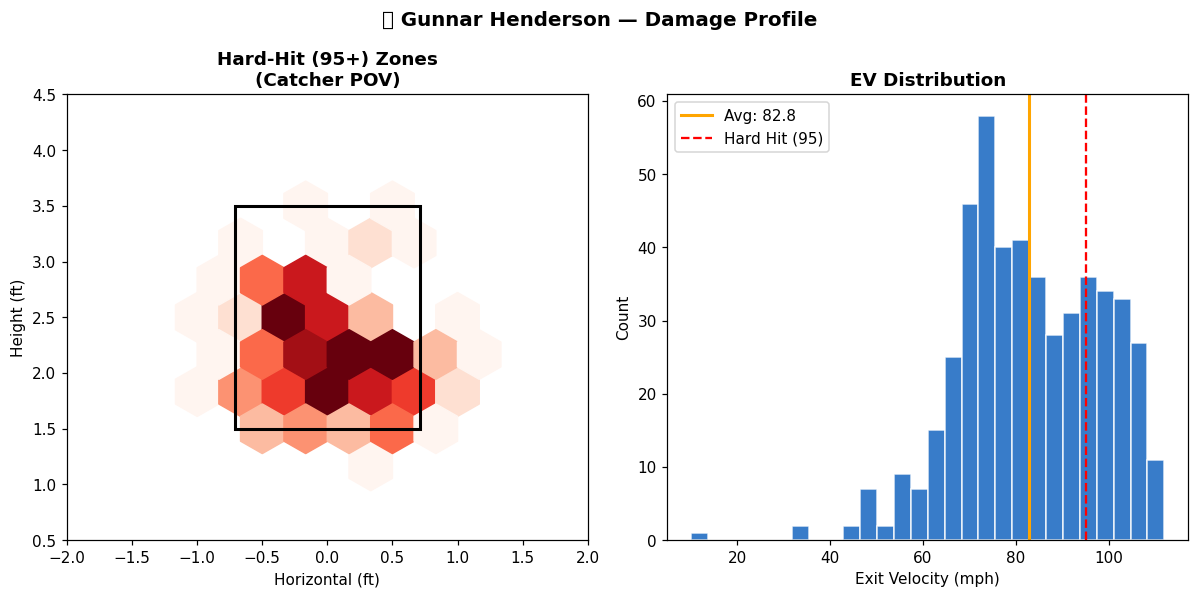

In [6]:
# ── 1b. Individual hitter damage map ──────────────────────
# ── CONFIGURE ─────────────────────────────────────────────
SCOUT_BATTER = ('henderson', 'gunnar')
# ──────────────────────────────────────────────────────────

bid = get_ids(*SCOUT_BATTER)
print(f'🔍 Scouting: {bid["name"]}')
sb  = batter_sc(bid['mlbam'])
bbe = sb[sb['launch_speed'].notna()]

# xwOBA and Whiff% by pitch type
if 'estimated_woba_using_speedangle' in sb.columns:
    by_pitch = sb.groupby('pitch_type').agg(
        Pitches   = ('pitch_type', 'count'),
        xwOBA     = ('estimated_woba_using_speedangle', 'mean'),
        Whiff_pct = ('description', lambda x:
                     x.isin(SWING_EVENTS).sum() /
                     max(x.isin(SWING_EVENTS+CONTACT_EVENTS).sum(), 1) * 100),
        Avg_EV    = ('launch_speed', 'mean'),
    ).reset_index()
    by_pitch['Pitch'] = by_pitch['pitch_type'].map(PITCH_NAMES).fillna(by_pitch['pitch_type'])
    by_pitch = by_pitch[by_pitch['Pitches'] >= 20].sort_values('xwOBA', ascending=False)
    print(f'\n🔴 High xwOBA = they PUNISH it   |   🟢 High Whiff = ATTACK here')
    display(by_pitch[['Pitch','Pitches','xwOBA','Whiff_pct','Avg_EV']].set_index('Pitch').round(3))

# Damage zone heatmap + EV distribution
hard = bbe[bbe['launch_speed'] >= 95]
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
fig.suptitle(f'💥 {bid["name"]} — Damage Profile', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hexbin(hard['plate_x'], hard['plate_z'], gridsize=12, cmap='Reds',
          mincnt=1, extent=[-2, 2, 0.5, 4.5])
ax.add_patch(patches.Rectangle((-0.708,1.5),1.416,2.0,lw=2,edgecolor='black',facecolor='none'))
ax.set_xlim(-2, 2); ax.set_ylim(0.5, 4.5)
ax.set_title('Hard-Hit (95+) Zones\n(Catcher POV)', fontweight='bold')
ax.set_xlabel('Horizontal (ft)'); ax.set_ylabel('Height (ft)')

ax2 = axes[1]
ax2.hist(bbe['launch_speed'].dropna(), bins=28, color='#1565C0', edgecolor='white', alpha=0.85)
ax2.axvline(bbe['launch_speed'].mean(), color='orange', lw=2,
            label=f"Avg: {bbe['launch_speed'].mean():.1f}")
ax2.axvline(95, color='red', lw=1.5, ls='--', label='Hard Hit (95)')
ax2.set_xlabel('Exit Velocity (mph)'); ax2.set_ylabel('Count')
ax2.set_title('EV Distribution', fontweight='bold'); ax2.legend()

plt.tight_layout(); plt.show()

---
# 🟠 2. Team Evaluation
*"Where are our gaps? Who should play more?"*

⚾ WSH — hitters with 50+ PA, ranked by xwOBA


,PA,xwOBA,wOBA,Avg_EV,HardHit%,Barrel%,Whiff%,Chase%
Name,,,,,,,,
"Wolfram, Grant",115,0.505,0.314,85.888,33.945,15.000,35.165,26.217
"Wolfram, Grant",84,0.479,0.479,83.994,26.190,16.418,18.125,39.000
"Suárez, Albert",98,0.424,0.304,83.310,29.310,11.594,30.601,34.104
"Suárez, Albert",91,0.396,0.306,80.377,22.222,10.938,16.667,28.019
"Suárez, Albert",51,0.380,0.405,80.024,23.881,6.977,20.690,28.395
"Helsley, Ryan",74,0.340,0.390,77.582,10.101,0.000,22.667,25.874
"Suárez, Albert",66,0.322,0.280,83.870,21.839,8.333,19.492,33.333
"Suárez, Albert",93,0.314,0.308,83.829,26.724,7.812,31.492,45.087
"Suárez, Albert",97,0.312,0.298,81.495,16.552,3.947,18.182,36.082



💡 High production, lower usage — candidates for more PA:


,PA,xwOBA,HardHit%
Name,,,
"Suárez, Albert",51,0.380,23.881


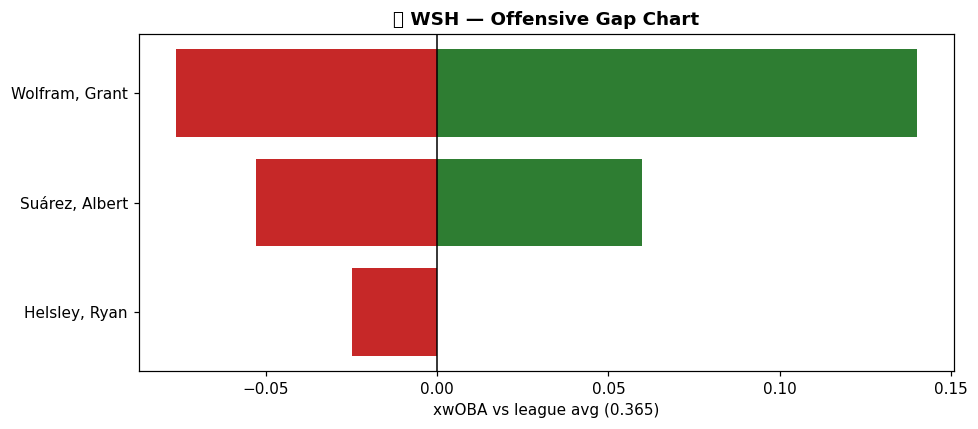

In [8]:
# ── CONFIGURE ─────────────────────────────────────────────
MY_TEAM  = 'WSH'   # Statcast abbreviation — print list above if unsure
MIN_PA   = 50
# ──────────────────────────────────────────────────────────

# Reuse sc from View 1 if same window, else pull:
# sc = statcast(START, END)

df = sc.copy()
df['bat_team'] = np.where(df['inning_topbot']=='Bot', df['home_team'], df['away_team'])
team_df = df[df['bat_team'] == MY_TEAM]

bat_rows = []
for batter_id, grp in team_df.groupby('batter'):
    pa = grp['events'].notna().sum()
    if pa < MIN_PA: continue
    name_vals = grp['player_name'].dropna()
    name = name_vals.iloc[0] if not name_vals.empty else str(batter_id)
    q    = quality_summary(grp)
    q['Name'] = name; q['PA'] = pa
    bat_rows.append(q)

roster = pd.DataFrame(bat_rows).sort_values('xwOBA', ascending=False)
SHOW = ['Name','PA','xwOBA','wOBA','Avg_EV','HardHit%','Barrel%','Whiff%','Chase%']
print(f'⚾ {MY_TEAM} — hitters with {MIN_PA}+ PA, ranked by xwOBA')
display(roster[[c for c in SHOW if c in roster.columns]].set_index('Name').round(3))

# 💡 Productive but low-usage (high xwOBA, low PA vs teammates)
if 'xwOBA' in roster.columns:
    roster['xwOBA_p'] = roster['xwOBA'].rank(pct=True) * 100
    roster['PA_p']    = roster['PA'].rank(pct=True) * 100
    under = roster[(roster['xwOBA_p'] > 55) & (roster['PA_p'] < 50)]
    if not under.empty:
        print('\n💡 High production, lower usage — candidates for more PA:')
        display(under[['Name','PA','xwOBA','HardHit%']].set_index('Name').round(3))

# Offensive gap chart vs league xwOBA
if 'xwOBA' in roster.columns and 'xwOBA' in league_off.columns:
    lg_xwoba = league_off['xwOBA'].mean()
    rv = roster[['Name','xwOBA']].dropna().sort_values('xwOBA', ascending=False)
    fig, ax = plt.subplots(figsize=(9, max(3, len(rv)*0.4)))
    ax.barh(rv['Name'], rv['xwOBA'] - lg_xwoba,
            color=['#2E7D32' if v>=lg_xwoba else '#C62828' for v in rv['xwOBA']])
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel(f'xwOBA vs league avg ({lg_xwoba:.3f})')
    ax.set_title(f'📊 {MY_TEAM} — Offensive Gap Chart', fontweight='bold')
    ax.invert_yaxis(); plt.tight_layout(); plt.show()

---
# 🟢 3. Player Development
*"What separates me from better peers? How do I track progress?"*

### 3a · Peer gap analysis
*OPS+ & rate stats from BBref, contact quality from Statcast.*

In [13]:
# ── CONFIGURE PLAYER DEVELOPMENT ──────────────────────────
DEV_PLAYER  = ('abrams', 'cj')
PEER_PA_MIN = 300
# ──────────────────────────────────────────────────────────

did = get_ids(*DEV_PLAYER)
sb  = batter_sc(did['mlbam'])
cq  = quality_summary(sb)

print(f'📋 {did["name"]} — {SEASON} Quality Metrics')
display(pd.DataFrame([{'Metric':k,'Value':round(v,3)}
        for k,v in cq.items() if k not in ('Pitches','BBE')]).set_index('Metric'))

# ── Peer pool from bulk Statcast pull ─────────────────────
print(f'\n⏳ Computing peer metrics from bulk pull (PA≥{PEER_PA_MIN})...')
peer_rows = []
for batter_id, grp in sc.groupby('batter'):
    if grp['events'].notna().sum() < PEER_PA_MIN: continue
    pq = quality_summary(grp); pq['batter'] = batter_id
    peer_rows.append(pq)
peers = pd.DataFrame(peer_rows)
print(f'✅ {len(peers)} qualifying peers')

DEV_METRICS = {
    'xwOBA':      False, 'wOBA':      False,
    'Avg_EV':     False, 'HardHit%':  False,
    'Barrel%':    False, 'SweetSpot%':False,
    'Chase%':     True,  'Whiff%':    True,
    'CSW%':       True,
}
gap_rows = []
for metric, lower in DEV_METRICS.items():
    if metric not in peers.columns or metric not in cq: continue
    p = pctile(peers[metric], cq[metric], lower)
    gap_rows.append({'Metric': metric, 'Value': round(cq[metric],3), 'Pctile': p})
gap = pd.DataFrame(gap_rows)

if not gap.empty:
    gap = gap.sort_values('Pctile')
    print(f'\n🎯 {did["name"]} vs peers — lowest Pctile = biggest opportunity')
    display(gap.set_index('Metric'))

    colors = ['#1B5E20' if p>=66 else '#F9A825' if p>=33 else '#B71C1C' for p in gap['Pctile']]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.barh(gap['Metric'], gap['Pctile'], color=colors)
    ax.axvline(50, color='gray', ls='--'); ax.set_xlim(0, 100)
    ax.set_xlabel('Percentile vs peers')
    ax.set_title(f'🟢 {did["name"]} — Development Gap Map', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print(f'\n⚠️ No qualifying peers (PA≥{PEER_PA_MIN}) found in the data for percentile comparison.')
    print('Consider adjusting PEER_PA_MIN or the Statcast pull date range.')

📋 Cj Abrams — 2026 Quality Metrics


,Value
Metric,
Avg_EV,83.892
Max_EV,110.100
Avg_LA,21.552
Barrel%,5.213
HardHit%,26.540
SweetSpot%,31.043
xwOBA,0.393
xBA,0.339
wOBA,0.387



⏳ Computing peer metrics from bulk pull (PA≥300)...
✅ 0 qualifying peers

⚠️ No qualifying peers (PA≥300) found in the data for percentile comparison.
Consider adjusting PEER_PA_MIN or the Statcast pull date range.


### 3b · In-season progress tracking
*Rolling 15-batted-ball exit velocity & hard-hit rate.*

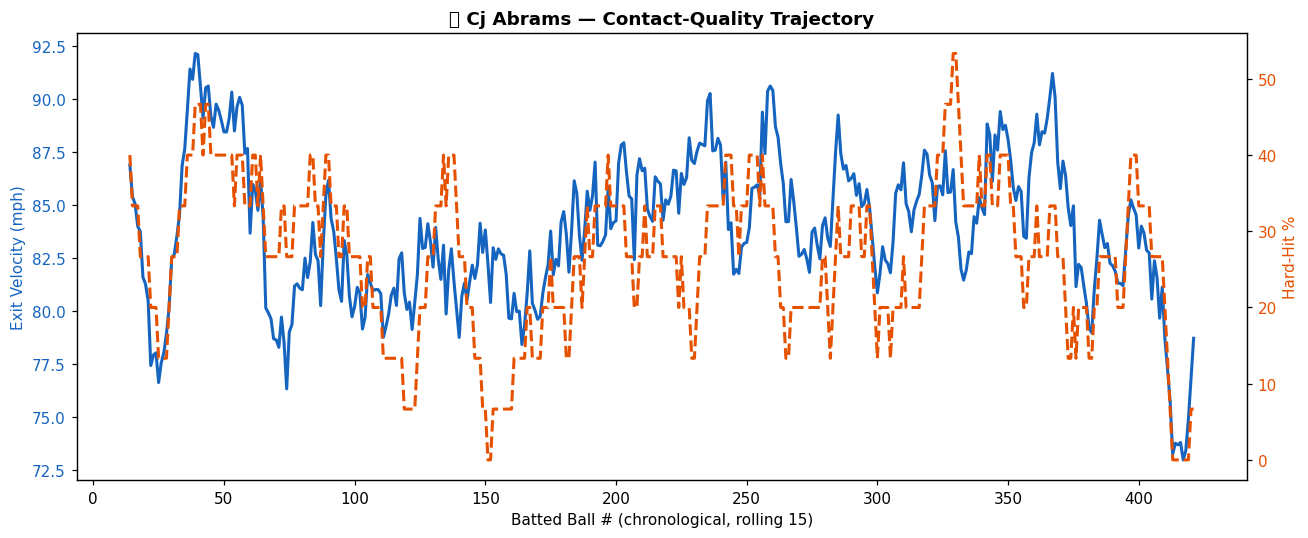


📅 Cj Abrams — Monthly Breakdown


,xwOBA,wOBA,Avg_EV,HardHit%,Barrel%,Whiff%,Chase%
month,,,,,,,
2026-04,0.460,0.432,83.140,30.147,7.353,27.551,34.034
2026-05,0.394,0.406,84.537,23.529,4.118,27.451,33.333
2026-06,0.314,0.308,83.829,26.724,4.310,31.492,45.087


In [14]:
# ── 3b. In-season rolling progress + monthly breakdown ────
bbe = sb[sb['launch_speed'].notna()].sort_values('game_date').reset_index(drop=True)

if len(bbe) < 20:
    print('⚠️  Not enough batted balls for rolling view.')
else:
    W = 15
    bbe['roll_EV'] = bbe['launch_speed'].rolling(W).mean()
    bbe['roll_HH'] = (bbe['launch_speed'] >= 95).rolling(W).mean() * 100

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(bbe.index, bbe['roll_EV'], color='#1565C0', lw=2, label='Avg EV')
    ax1.set_ylabel('Exit Velocity (mph)', color='#1565C0')
    ax1.tick_params(axis='y', labelcolor='#1565C0')
    ax2 = ax1.twinx()
    ax2.plot(bbe.index, bbe['roll_HH'], color='#E65100', lw=2, ls='--', label='Hard-Hit%')
    ax2.set_ylabel('Hard-Hit %', color='#E65100')
    ax2.tick_params(axis='y', labelcolor='#E65100')
    ax1.set_xlabel(f'Batted Ball # (chronological, rolling {W})')
    ax1.set_title(f'📈 {did["name"]} — Contact-Quality Trajectory', fontweight='bold')
    plt.tight_layout(); plt.show()

# Monthly breakdown
sb['month'] = pd.to_datetime(sb['game_date'].astype(str)).dt.to_period('M')
monthly = (sb.groupby('month')
             .apply(lambda g: pd.Series(quality_summary(g)))
             .reset_index())
MCOLS = [c for c in ['month','xwOBA','wOBA','Avg_EV','HardHit%','Barrel%','Whiff%','Chase%']
         if c in monthly.columns]
print(f'\n📅 {did["name"]} — Monthly Breakdown')
display(monthly[MCOLS].set_index('month').round(3))

---
# 🔵 4. Agents
*"What makes my player unique? What's fair market value?"*

### 4a · Elite-skill spotlight (the touting case)
*BBref rate stats + Statcast quality, ranked vs qualified peers.*

In [19]:
# ── CONFIGURE ─────────────────────────────────────────────
CLIENT = ('ohtani', 'shohei')
# ──────────────────────────────────────────────────────────

cid = get_ids(*CLIENT)
csb = batter_sc(cid['mlbam'])
cq  = quality_summary(csb)

# ── Rebuild peers if View 3 was skipped ───────────────────
if 'peers' not in dir() or peers.empty:
    print('⏳ Building peer pool...')
    peer_rows = []
    for batter_id, grp in sc.groupby('batter'):
        if grp['events'].notna().sum() < 300: continue
        pq = quality_summary(grp); pq['batter'] = batter_id
        peer_rows.append(pq)
    peers = pd.DataFrame(peer_rows)
    print(f'✅ {len(peers)} peers built')

# ── Diagnostic ────────────────────────────────────────────
print('cq keys   :', list(cq.keys()))
print('peers cols:', list(peers.columns))

AGENT_METRICS = {
    'xwOBA':      False, 'wOBA':       False,
    'Avg_EV':     False, 'Max_EV':     False,
    'HardHit%':   False, 'Barrel%':    False,
    'SweetSpot%': False,
    'Chase%':     True,  'Whiff%':     True,
}

agent_rows = []
for metric, lower in AGENT_METRICS.items():
    if metric not in peers.columns:
        print(f'⚠️  {metric} missing from peers'); continue
    if metric not in cq:
        print(f'⚠️  {metric} missing from cq'); continue
    p = pctile(peers[metric], cq[metric], lower)
    agent_rows.append({'Metric': metric, 'Value': round(cq[metric],3), 'Pctile': p})

if not agent_rows:
    print('❌ No metrics matched — check diagnostics above')
else:
    prof = pd.DataFrame(agent_rows).sort_values('Pctile', ascending=False)
    print(f'⭐ {cid["name"]} — {SEASON} Statcast Percentile Profile')
    display(prof.set_index('Metric'))

    elite = prof[prof['Pctile'] >= 90]
    if not elite.empty:
        print('\n🌟 ELITE (90th+) — touting headline:')
        for _, r in elite.iterrows():
            print(f"   • {r['Metric']}: {r['Value']} ({int(r['Pctile'])}th pct)")

    colors = ['#FFD600' if p>=90 else '#1B5E20' if p>=66 else '#F9A825' if p>=33 else '#B71C1C'
              for p in prof['Pctile']]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(prof['Metric'], prof['Pctile'], color=colors, edgecolor='black', lw=0.5)
    ax.axvline(90, color='gold', lw=2, label='Elite (90th)')
    ax.set_xlim(0, 100); ax.legend(); ax.invert_yaxis()
    ax.set_title(f'🔵 {cid["name"]} — Skill Percentile Profile', fontweight='bold')
    plt.tight_layout(); plt.show()

⏳ Building peer pool...
✅ 0 peers built
cq keys   : ['Pitches', 'BBE', 'Avg_EV', 'Max_EV', 'Avg_LA', 'Barrel%', 'HardHit%', 'SweetSpot%', 'xwOBA', 'xBA', 'wOBA', 'Chase%', 'Whiff%', 'CSW%']
peers cols: []
⚠️  xwOBA missing from peers
⚠️  wOBA missing from peers
⚠️  Avg_EV missing from peers
⚠️  Max_EV missing from peers
⚠️  HardHit% missing from peers
⚠️  Barrel% missing from peers
⚠️  SweetSpot% missing from peers
⚠️  Chase% missing from peers
⚠️  Whiff% missing from peers
❌ No metrics matched — check diagnostics above


### 4b · Surplus value / contract valuation
*Market value (WAR × $/WAR) vs salary. Needs `contracts.csv` with columns `Name, bbref, Salary`.*

In [ ]:
# ── 4b. Surplus value / contract valuation ────────────────
# contracts.csv columns: Name, mlbam, Salary
import os

CONTRACTS_CSV = 'contracts.csv'
# In Colab point to Drive:
# CONTRACTS_CSV = '/content/drive/My Drive/MLB Analytics/contracts.csv'

if not os.path.exists(CONTRACTS_CSV):
    pd.DataFrame({
        'Name'  : ['Aaron Judge', 'Gunnar Henderson', 'CJ Abrams'],
        'mlbam' : [592450, 683002, 682928],
        'Salary': [40000000, 1000000, 800000],
    }).to_csv(CONTRACTS_CSV, index=False)
    print('📝 Template written — edit Salary column and re-run.')

contracts = pd.read_csv(CONTRACTS_CSV)

# WAR proxy uses already-loaded statcast_batter data — no extra network call
def get_war_proxy(mlbam):
    try:
        df = batter_sc(int(mlbam))  # cached after first pull
        return batting_war_proxy(df)
    except Exception:
        return 0.0

print('⏳ Computing batting WAR proxy per player (uses cache after first run)...')
contracts['WAR_proxy']    = contracts['mlbam'].apply(get_war_proxy)
contracts['Market_Value'] = contracts['WAR_proxy'] * DOLLARS_PER_WAR
contracts['Surplus']      = contracts['Market_Value'] - contracts['Salary']
contracts['Ratio']        = contracts['Market_Value'] / contracts['Salary'].replace(0, np.nan)

vd = contracts.copy()
for c in ['Salary','Market_Value','Surplus']:
    vd[c] = vd[c].apply(lambda x: f'${x/1e6:.1f}M' if pd.notna(x) else '—')
vd['Ratio'] = vd['Ratio'].round(2)
print(f'\n💰 Surplus Value {SEASON}  (batting WAR proxy × ${DOLLARS_PER_WAR/1e6:.0f}M)')
print('⚠️  WAR proxy = batting contribution only (no defense/baserunning)')
display(vd[['Name','WAR_proxy','Salary','Market_Value','Surplus','Ratio']].set_index('Name'))

fig, ax = plt.subplots(figsize=(9, max(3, len(contracts)*0.5)))
ax.barh(contracts['Name'], contracts['Surplus']/1e6,
        color=['#2E7D32' if s>0 else '#C62828' for s in contracts['Surplus']])
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Surplus ($M) — 🟢 green = underpaid vs batting production')
ax.set_title(f'💵 Surplus Value — {SEASON}', fontweight='bold')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

---
# 📋 Reference
---



### ✅ Statcast columns used
| Metric | Column |
|---|---|
| Exit Velocity | `launch_speed` |
| Launch Angle | `launch_angle` |
| Barrel | `launch_speed_angle == 6` |
| Hard Hit | `launch_speed >= 95` |
| Sweet Spot | `launch_angle` between 8–32° |
| xwOBA | `estimated_woba_using_speedangle` |
| xBA | `estimated_ba_using_speedangle` |
| wOBA (actual) | `woba_value / woba_denom` |
| Whiff% | `description` in swing miss codes |
| Chase% | out-of-zone `zone` + swing `description` |
| CSW% | called strikes + whiffs / total pitches |

### ⚠️ Known limitations
- **WAR proxy is batting-only** — no defense or baserunning. Use as a floor, not a true WAR estimate.
- **`LG_WOBA` and `WOBA_SCALE`** — update each season from baseballsavant.mlb.com/league.
- **Team abbreviations** — Statcast uses `WSH`, `ARI`, `CWS`, etc. Print `sc['home_team'].unique()` if a team is missing.
- **Bulk pulls are large** — ~700k rows/month. Narrow `SCOUT_START`/`SCOUT_END` and let the cache handle repeats. Run `pb.cache.purge()` if results look stale.
- **Peer pool** is scoped to the same bulk pull window. A full-season peer pool needs a full-season pull.

### 🔧 Each new season
1. Update `SEASON`, `START`, `END`
2. Update `LG_WOBA` from Baseball Savant league page
3. Update `DOLLARS_PER_WAR` (~$8–9M for 2025)
4. Run `pb.cache.purge()` to clear prior-season cache